# Strong coupling expansion
Compute the average denstity $$\langle n \rangle = -\frac{\partial}{\partial \mu} \Omega$$
where $\Omega = -k_BT \ln Z$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import h5py
from robustpade import pade_approx_batch

## Atomic limit exact results for order 0 and 2 

In [2]:
def Z_atomic(U:float, beta:float, mu:float):
    return 1 + 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))


def a_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return -1/beta*np.log(Zat) # factor 2 for spin and


def a_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!


U = 8.0


## Load files 

In [3]:
def load_data(U,beta, alpha):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]


    partial_sum_4 = a_0(U, beta, mus) + a_2(U, beta, mus) + a_4
    partial_sum_6 = partial_sum_4 + a_6


    n0 = -np.gradient(a_0(U, beta, mus), mus)
    n4 = -np.gradient(partial_sum_4, mus)
    n6 = -np.gradient(partial_sum_6, mus)

    return mus, n0, n4, n6, a_4, errors_4, a_6, errors_6

    


## Compare with CDet $U=8$, $\beta = 0.75$

In [4]:
U = 8.0
alpha = 0.001
mus, n0, n4, n6,_ ,_,_,_= load_data(U, beta=0.75, alpha=alpha)

In [5]:
Cdet = np.array([0.000000000000000000e+00, 6.577886434859689935e-01,
2.000000000000000111e-01, 6.830654739026462696e-01,
4.000000000000000222e-01, 7.076495052411750919e-01,
6.000000000000000888e-01, 7.314561757479093318e-01,
8.000000000000000444e-01, 7.544149325723877864e-01,
1.000000000000000000e+00, 7.764680082055557264e-01,
1.200000000000000178e+00, 7.975690887248386707e-01,
1.400000000000000133e+00, 8.176829680520789623e-01,
1.600000000000000089e+00, 8.367864676447966943e-01,
1.800000000000000044e+00, 8.548702023276939510e-01,
2.000000000000000000e+00, 8.719404788084273994e-01,
2.200000000000000178e+00, 8.880207016779730900e-01,
2.400000000000000355e+00, 9.031519434244016376e-01,
2.600000000000000089e+00, 9.173926215565577635e-01,
2.800000000000000266e+00, 9.308174158122632935e-01,
3.000000000000000000e+00, 9.435156370374528922e-01,
3.200000000000000178e+00, 9.555892585948051465e-01,
3.400000000000000355e+00, 9.671507808392967309e-01,
3.600000000000000089e+00, 9.783210477561885554e-01,
3.800000000000000266e+00, 9.892270864443353240e-01,
4.000000000000000000e+00, 9.999999999999955591e-01])

In [6]:
cdet_mus = Cdet[::2]
cdet_n = Cdet[1::2]

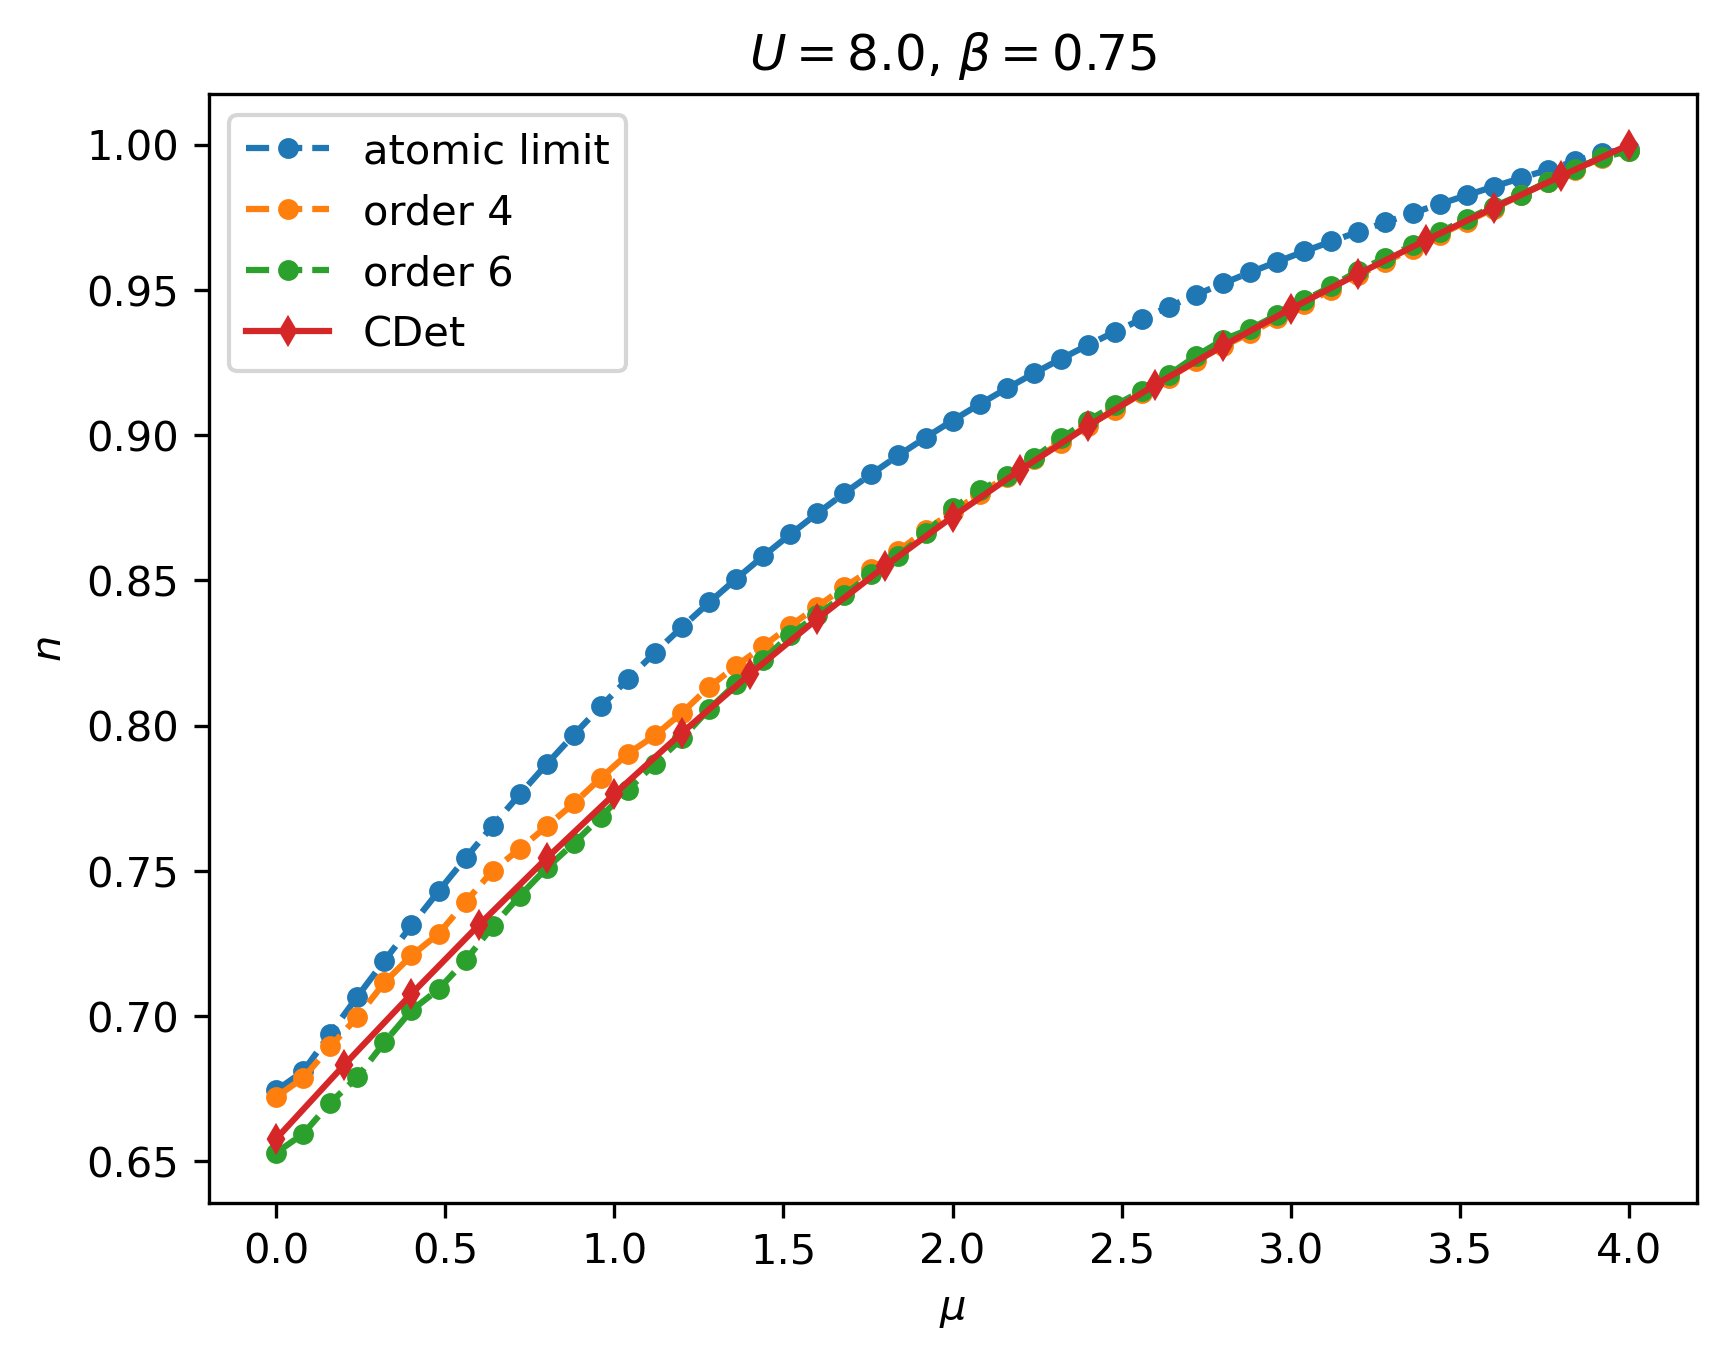

In [7]:
fig, ax = plt.subplots()
ax.plot(mus, n0, label='atomic limit', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n4, label='order 4', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n6, label='order 6', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(cdet_mus, cdet_n, label='CDet', marker = 'd', markersize=4)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$n$')
ax.set_title(r'$U=8.0$, $\beta=0.75$')
ax.legend()

## Precise derivative

In [8]:
cdet_mus = np.array([1.0, 1.5, 2.0])
cdet_n = np.array([0.761236, 0.838576, 0.905056])

afqmc_mus = np.array([2.0,2.5,3.0])
afqmc_n = np.array([8.9905500e-01, 9.4684639e-01, 9.7637588e-01])

## Derivative with polynomial fit

In [9]:
from scipy.optimize import curve_fit

In [14]:
U=8.0
beta=2.0
alpha= 0.01
def load_density(U,beta, alpha):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]

    a_0_values = a_0(U, beta, mus)
    a_2_values = a_2(U, beta, mus) 

    partial_sum_4 = a_0_values + a_2_values + a_4
    partial_sum_6 = partial_sum_4 + a_6

    error_partial_sum_4 = errors_4
    error_partial_sum_6 = np.sqrt(errors_4**2 + errors_6**2)

    return mus, partial_sum_4, partial_sum_6, error_partial_sum_4, error_partial_sum_6, a_4, a_6
    

In [15]:
mus, partial_sum_4, partial_sum_6, error_partial_sum_4, error_partial_sum_6, a_4, a_6 = load_density(U, beta=2.0, alpha=alpha)

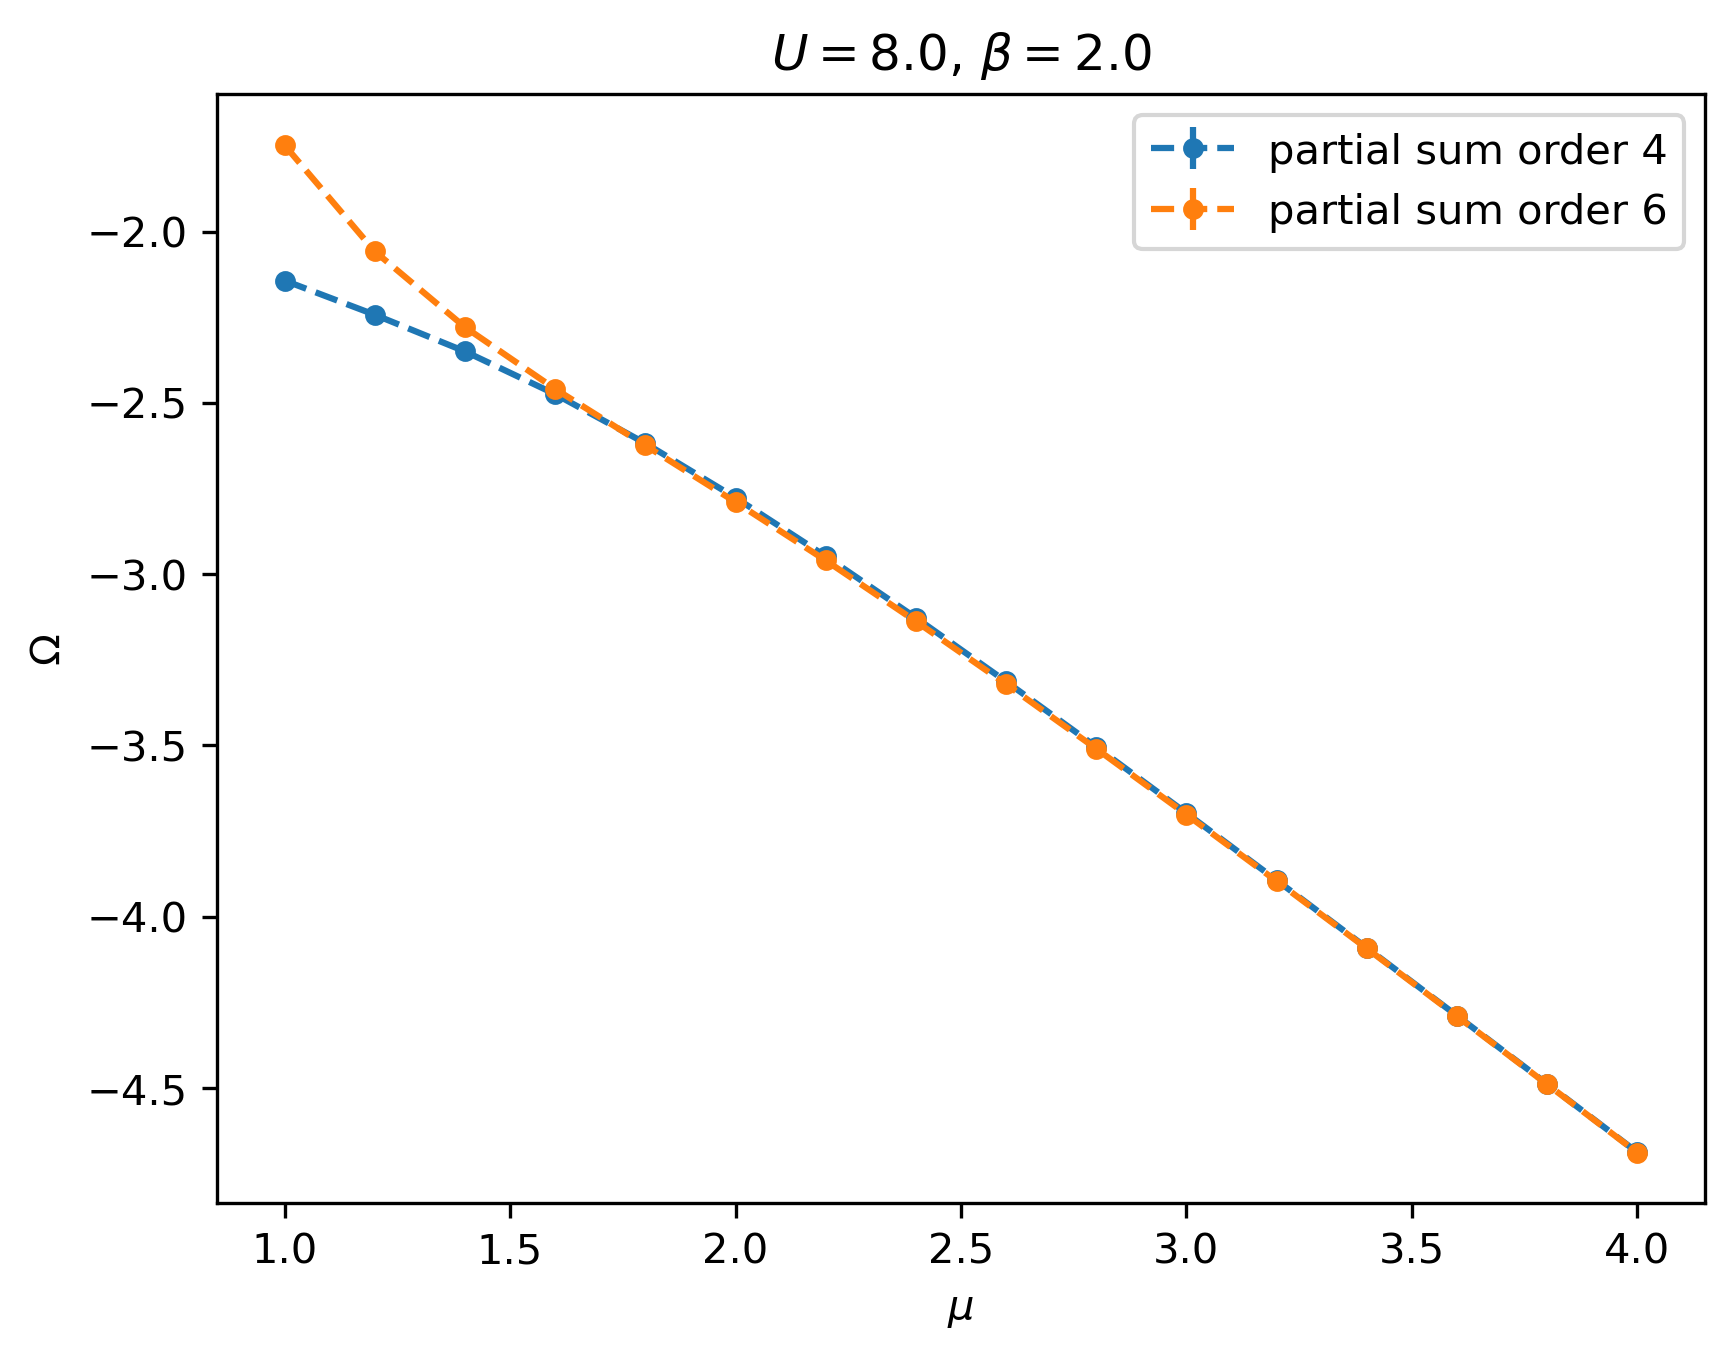

In [16]:
plt.errorbar(mus, partial_sum_4, yerr=error_partial_sum_4, label='partial sum order 4', marker = 'o', markersize=4, linestyle='dashed')
plt.errorbar(mus, partial_sum_6, yerr=error_partial_sum_6, label='partial sum order 6', marker = 'o', markersize=4, linestyle='dashed')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\Omega$')
plt.title(r'$U=8.0$, $\beta=2.0$')
plt.legend()

<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1961871090.py:43: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1961871090.py:44: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1961871090.py:55: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


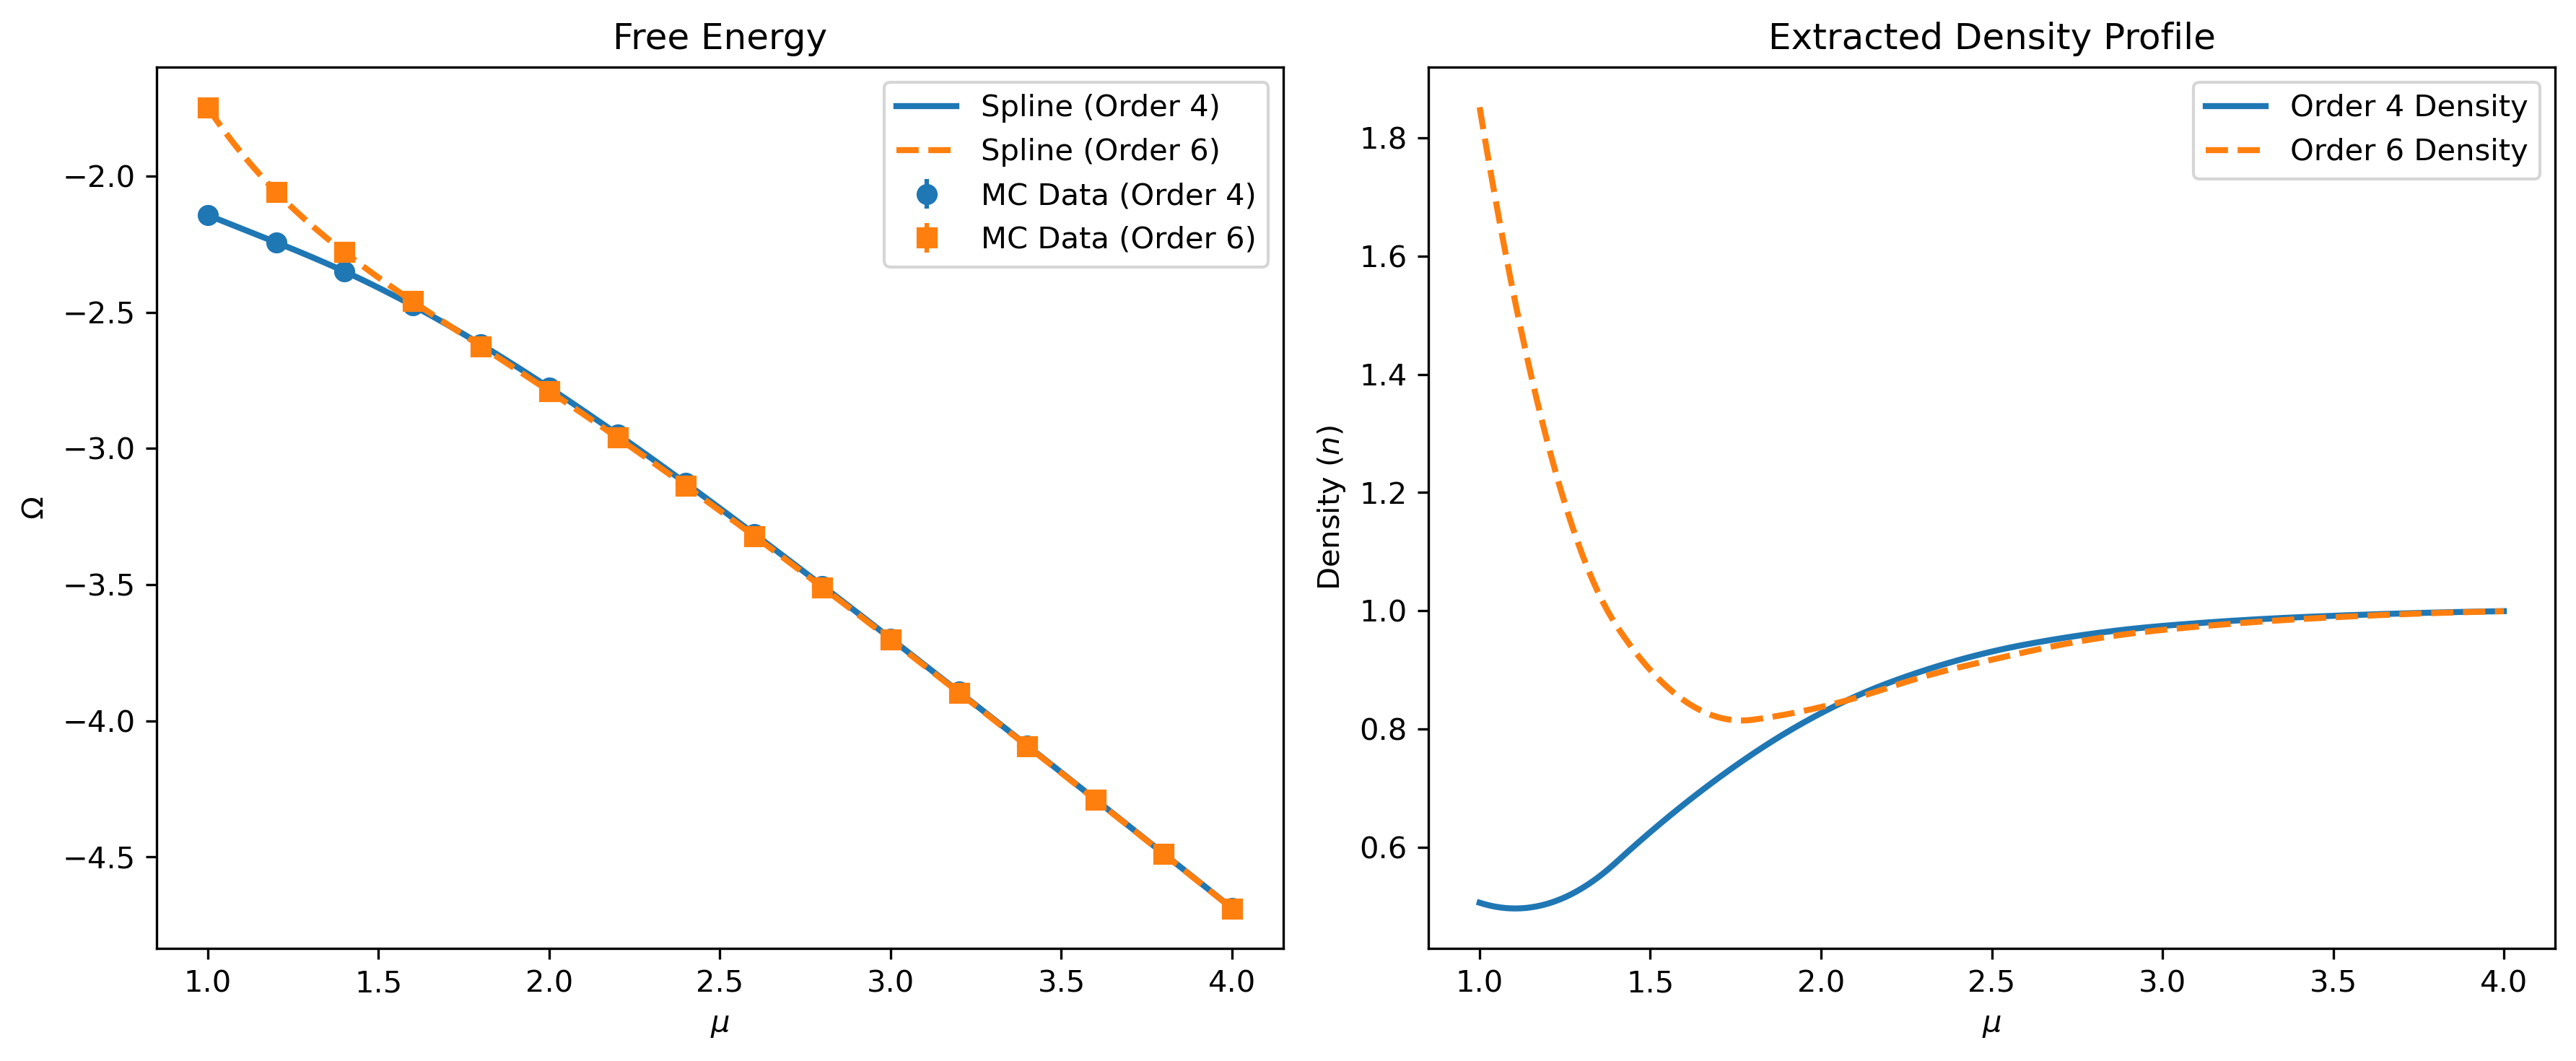

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Assume 'mus', 'partial_sum_4', 'partial_sum_6', 
# 'error_partial_sum_4', and 'error_partial_sum_6' are loaded as before.

# --- 1. Fit 4th Order Spline ---
weights_4 = 1.0 / error_partial_sum_4
spline_4 = UnivariateSpline(mus, partial_sum_4, w=weights_4, s=len(mus)*0.1)
derivative_spline_4 = spline_4.derivative(n=1)

# --- 2. Fit 6th Order Spline ---
weights_6 = 1.0 / error_partial_sum_6
spline_6 = UnivariateSpline(mus, partial_sum_6, w=weights_6, s=len(mus)*0.1)
derivative_spline_6 = spline_6.derivative(n=1)

# --- 3. Evaluate on dense grid ---
mu_dense = np.linspace(np.min(mus), np.max(mus), 200)

# 4th order evaluations
omega_smooth_4 = spline_4(mu_dense)
density_profile_4 = -derivative_spline_4(mu_dense)

# 6th order evaluations
omega_smooth_6 = spline_6(mu_dense)
density_profile_6 = -derivative_spline_6(mu_dense)

# --- 4. Plotting ---
plt.figure(figsize=(12, 5))

# Plot 1: The Free Energy Fit
plt.subplot(1, 2, 1)

# Plot Order 4 (Blue)
plt.errorbar(mus, partial_sum_4, yerr=error_partial_sum_4, fmt='o', color='tab:blue', label='MC Data (Order 4)')
plt.plot(mu_dense, omega_smooth_4, '-', color='tab:blue', lw=2, label='Spline (Order 4)')

# Plot Order 6 (Orange)
plt.errorbar(mus, partial_sum_6, yerr=error_partial_sum_6, fmt='s', color='tab:orange', label='MC Data (Order 6)')
plt.plot(mu_dense, omega_smooth_6, '--', color='tab:orange', lw=2, label='Spline (Order 6)')

plt.xlabel('$\mu$')
plt.ylabel('$\Omega$')
plt.title('Free Energy')
plt.legend()

# Plot 2: The Density Profile (Negative Derivative)
plt.subplot(1, 2, 2)

# I changed the scatter to a plot line for the dense grid, as it looks much cleaner for continuous derivatives.
plt.plot(mu_dense, density_profile_4, '-', color='tab:blue', lw=2, label='Order 4 Density')
plt.plot(mu_dense, density_profile_6, '--', color='tab:orange', lw=2, label='Order 6 Density')

plt.xlabel('$\mu$')
plt.ylabel('Density ($n$)')
plt.title('Extracted Density Profile')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
coeffs_mus = [a_0(U,beta,mus),a_2(U,beta,mus), a_4, a_6]
padé_21 = pade_approx_batch(coeffs_mus, (2,1))(1.0)
padé_12 = pade_approx_batch(coeffs_mus, (1,2))(1.0)

/opt/anaconda3/envs/strong_coupling_conda/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/strong_coupling_conda/lib/python3.13/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0, 0.5, '$\\Omega$')

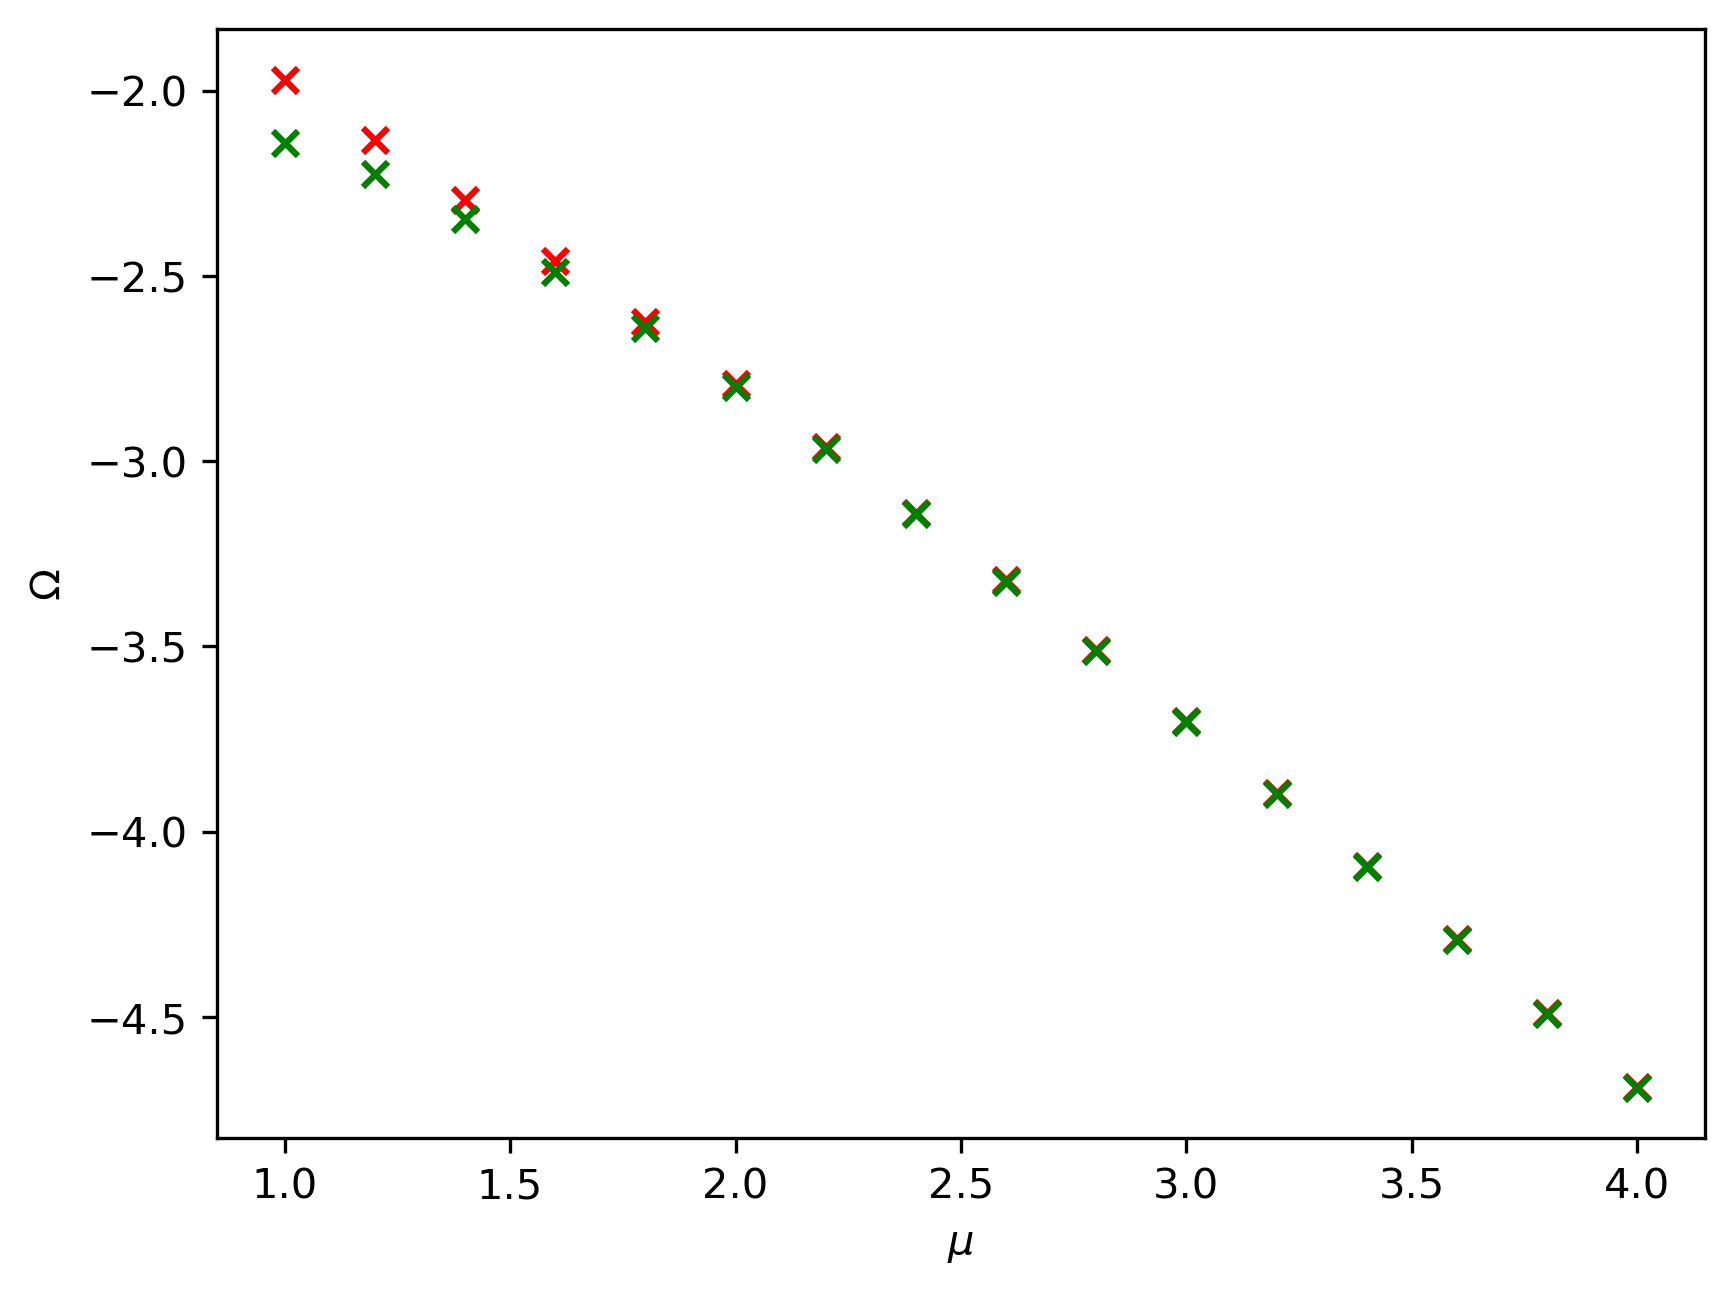

In [19]:
plt.scatter(mus, padé_21, label='Padé (2,1)', marker='x', color='red')
plt.scatter(mus, padé_12, label='Padé (1,2)', marker='x', color='green')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\Omega$')

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:61: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\O'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:61: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\O'
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/3287067247.py:59: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/3287067247.py:60: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/3287067247.py:61: SyntaxWarning: invalid escape sequence '\O'
  plt.title('Free Energy ($\Omega$) Resummation')
/var/folders/74

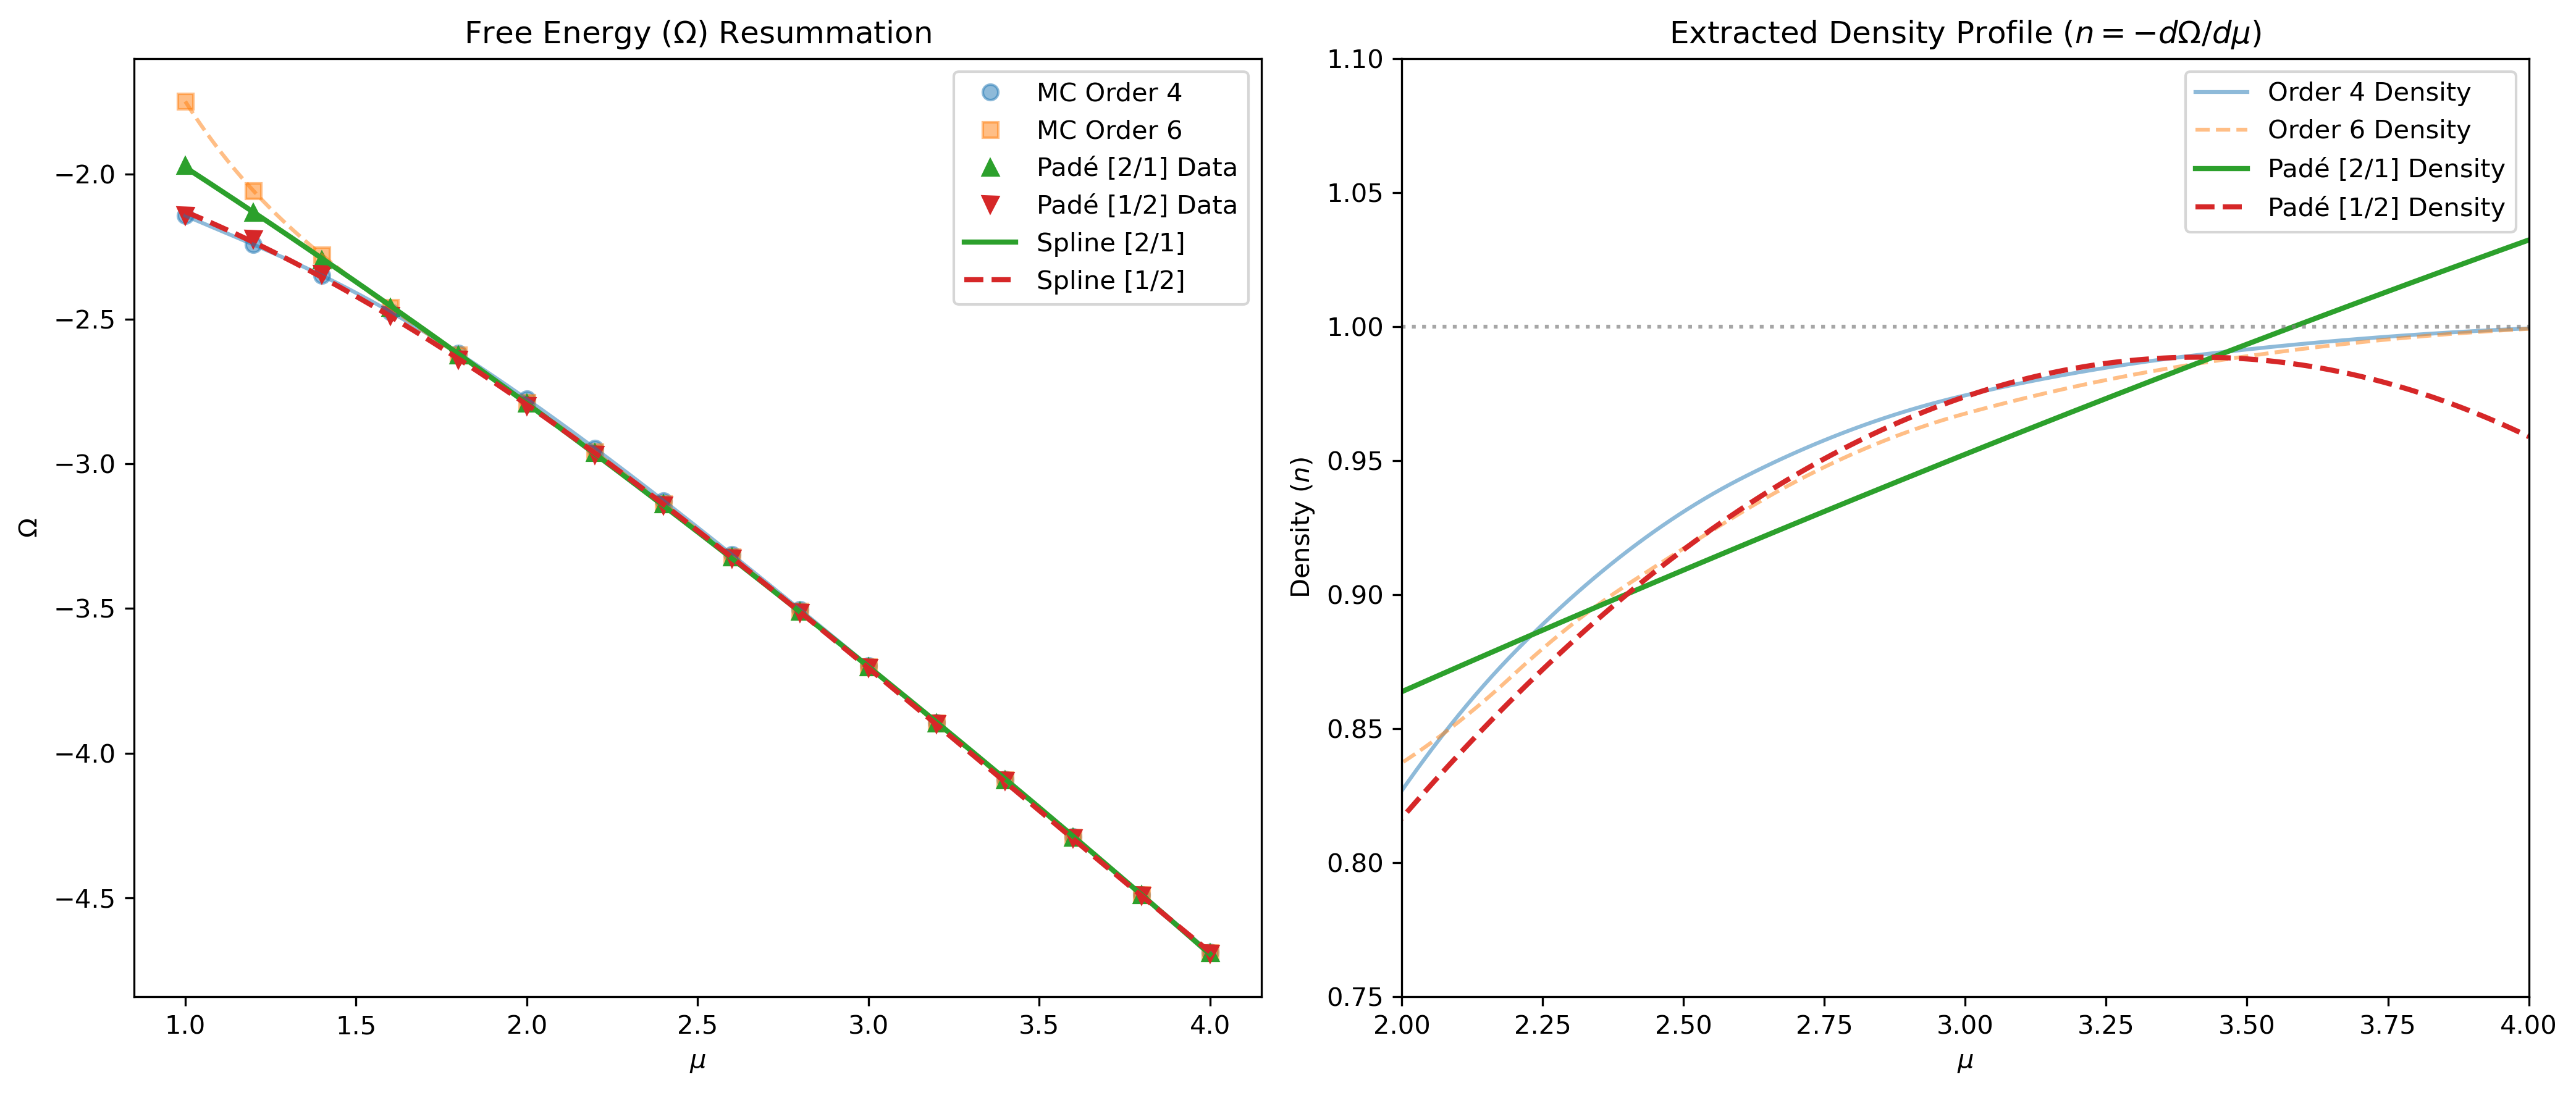

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Assume 'mus', 'partial_sum_4', 'partial_sum_6', 'error_partial_sum_4', 'error_partial_sum_6' are loaded
# Assume 'coeffs_mus' is defined as: coeffs_mus = [a_0(U,beta,mus), a_2(U,beta,mus), a_4, a_6]
# Assume 'pade_approx_batch' is available in your environment

# --- 1. Calculate Padé Approximants ---
pade_21 = pade_approx_batch(coeffs_mus, (2,1))(1.0)
pade_12 = pade_approx_batch(coeffs_mus, (1,2))(1.0)

# --- 2. Fit Splines ---
# For the raw MC sums, we keep the statistical weights
s_factor = len(mus) * 0.1

spline_4 = UnivariateSpline(mus, partial_sum_4, w=1.0/error_partial_sum_4, s=s_factor)
spline_6 = UnivariateSpline(mus, partial_sum_6, w=1.0/error_partial_sum_6, s=s_factor)

# For Padé, we don't have exact propagated errors, so we use an unweighted spline.
# We keep a small smoothing factor to ensure the derivative is well-behaved.
spline_p21 = UnivariateSpline(mus, pade_21, s=s_factor * 0.1) 
spline_p12 = UnivariateSpline(mus, pade_12, s=s_factor * 0.1)

# --- 3. Calculate Derivatives ---
deriv_4 = spline_4.derivative(n=1)
deriv_6 = spline_6.derivative(n=1)
deriv_p21 = spline_p21.derivative(n=1)
deriv_p12 = spline_p12.derivative(n=1)

# --- 4. Evaluate on dense grid ---
mu_dense = np.linspace(np.min(mus), np.max(mus), 200)

omega_4 = spline_4(mu_dense)
omega_6 = spline_6(mu_dense)
omega_p21 = spline_p21(mu_dense)
omega_p12 = spline_p12(mu_dense)

density_4 = -deriv_4(mu_dense)
density_6 = -deriv_6(mu_dense)
density_p21 = -deriv_p21(mu_dense)
density_p12 = -deriv_p12(mu_dense)

# --- 5. Plotting ---
plt.figure(figsize=(14, 6))

# Plot 1: Free Energy
plt.subplot(1, 2, 1)
plt.plot(mus, partial_sum_4, 'o', color='tab:blue', alpha=0.5, label='MC Order 4')
plt.plot(mus, partial_sum_6, 's', color='tab:orange', alpha=0.5, label='MC Order 6')
plt.plot(mus, pade_21, '^', color='tab:green', label='Padé [2/1] Data')
plt.plot(mus, pade_12, 'v', color='tab:red', label='Padé [1/2] Data')

plt.plot(mu_dense, omega_4, '-', color='tab:blue', alpha=0.5)
plt.plot(mu_dense, omega_6, '--', color='tab:orange', alpha=0.5)
plt.plot(mu_dense, omega_p21, '-', color='tab:green', lw=2, label='Spline [2/1]')
plt.plot(mu_dense, omega_p12, '--', color='tab:red', lw=2, label='Spline [1/2]')

plt.xlabel('$\mu$')
plt.ylabel('$\Omega$')
plt.title('Free Energy ($\Omega$) Resummation')
plt.legend()

# Plot 2: Density Profile
plt.subplot(1, 2, 2)
plt.plot(mu_dense, density_4, '-', color='tab:blue', alpha=0.5, label='Order 4 Density')
plt.plot(mu_dense, density_6, '--', color='tab:orange', alpha=0.5, label='Order 6 Density')
plt.plot(mu_dense, density_p21, '-', color='tab:green', lw=2, label='Padé [2/1] Density')
plt.plot(mu_dense, density_p12, '--', color='tab:red', lw=2, label='Padé [1/2] Density')

plt.xlim(2.0,4.0)
plt.ylim(0.75,1.1)

# Add a horizontal line at 1.0 to easily check the high-mu asymptote
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)

plt.xlabel('$\mu$')
plt.ylabel('Density ($n$)')
plt.title('Extracted Density Profile ($n = -d\Omega/d\mu$)')
plt.legend()

plt.tight_layout()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\O'
<>:79: SyntaxWarning: invalid escape sequence '\O'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\O'
<>:79: SyntaxWarning: invalid escape sequence '\O'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\O'
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1887622257.py:77: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1887622257.py:78: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')
/var/folders/74/hmrv43115x7gxdncjlkh1kdm0000gn/T/ipykernel_5553/1887622257.py:79: SyntaxWarning: invalid escape sequence '\O'
  plt.title('Free Energy ($\Omega$) Resummation')
/var/folder

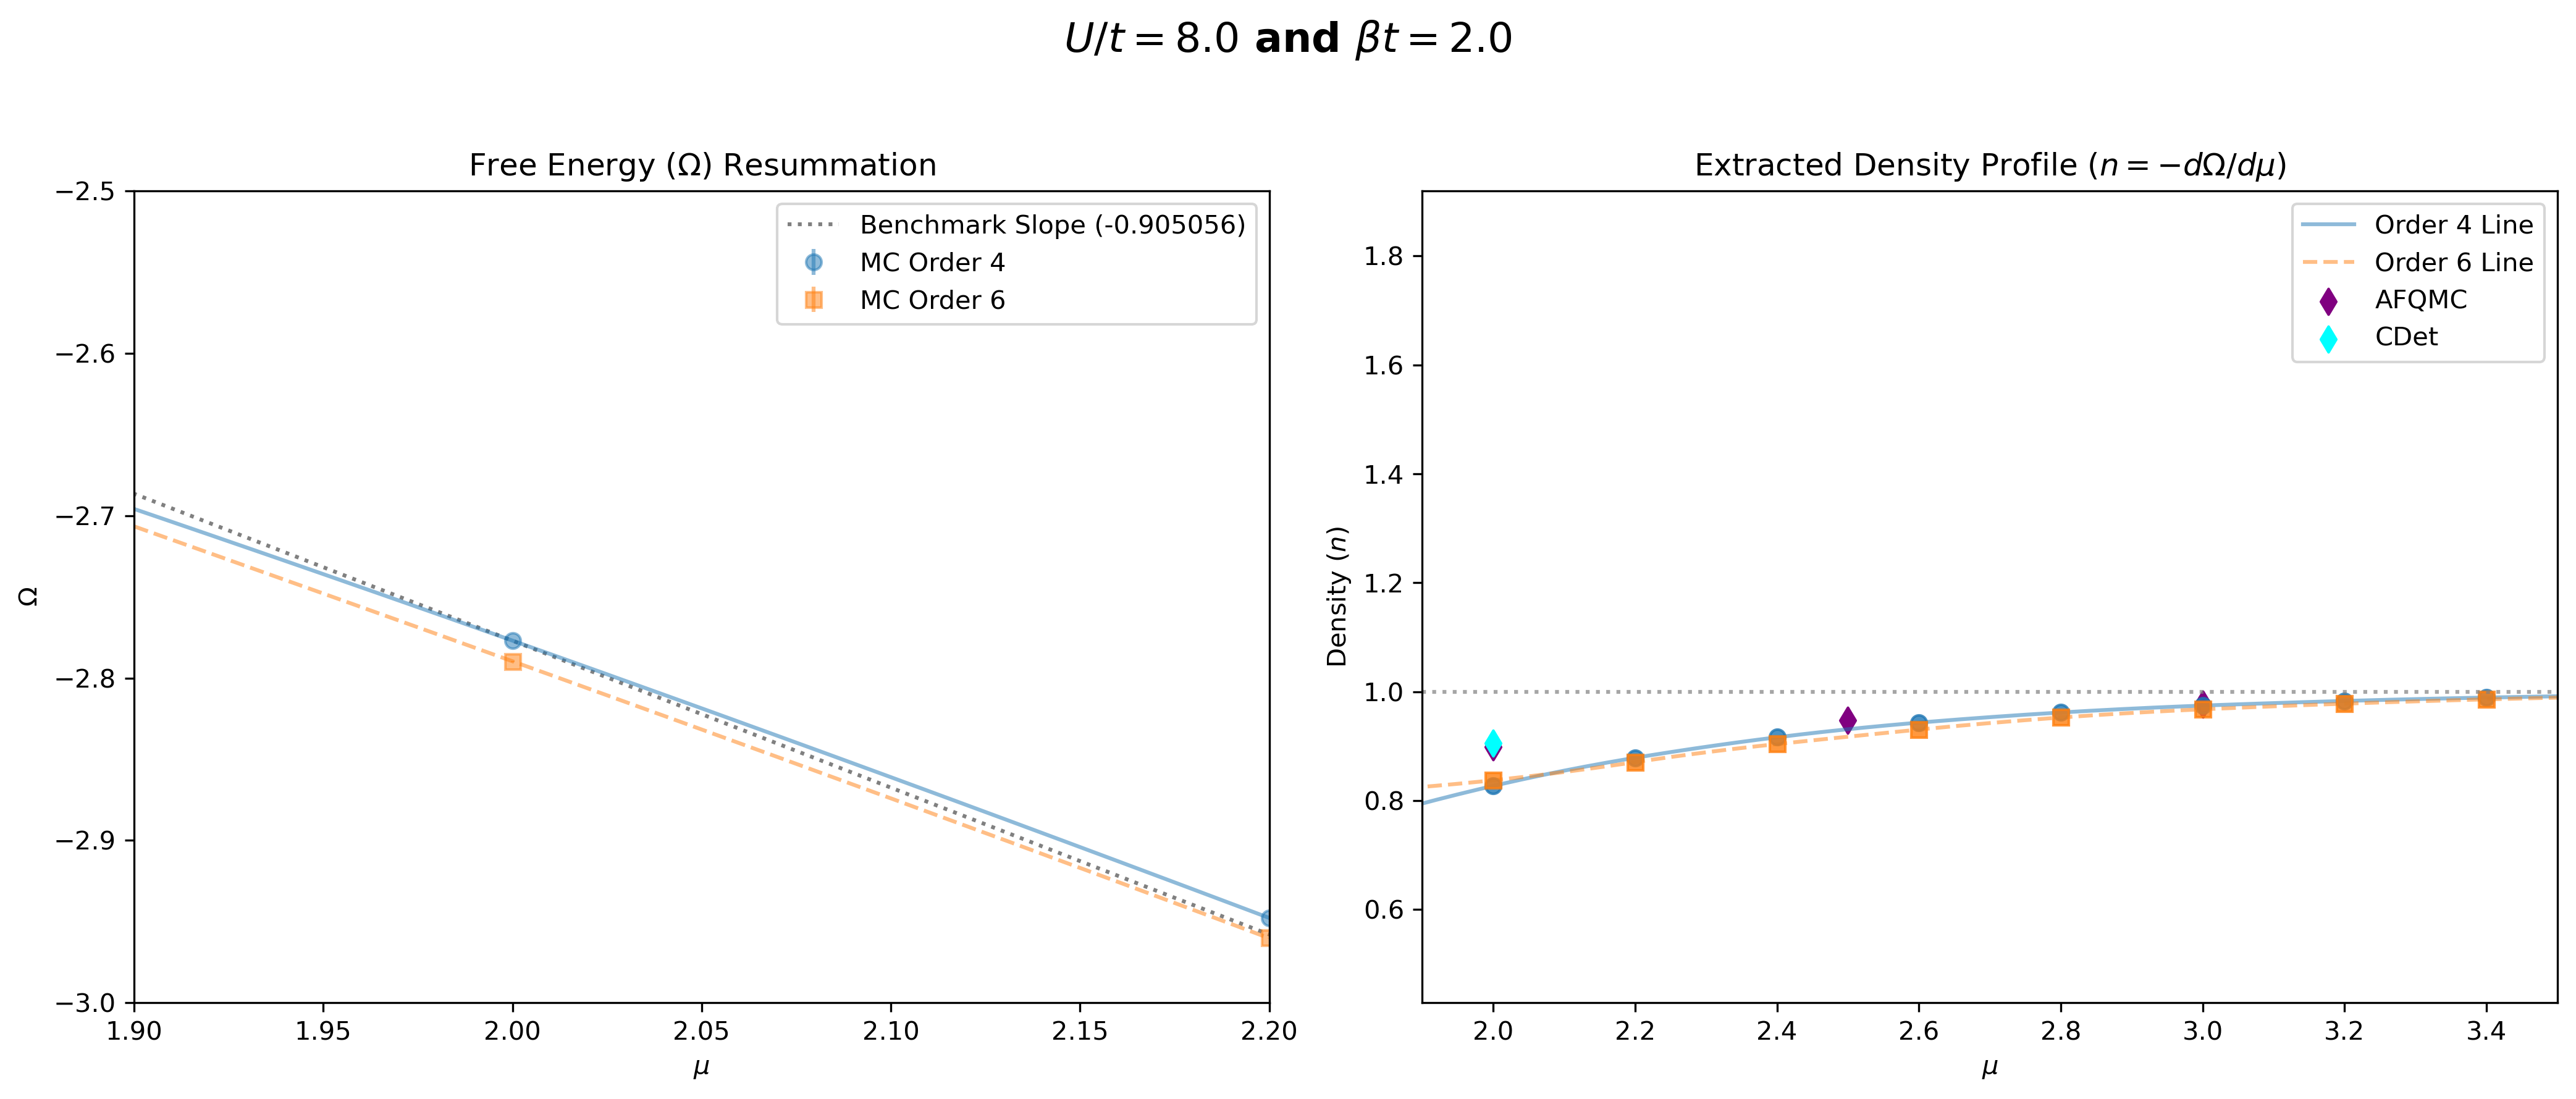

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, PchipInterpolator

# Assume 'mus', 'partial_sum_4', 'partial_sum_6', 'error_partial_sum_4', 'error_partial_sum_6' are loaded
# Assume 'coeffs_mus' is defined as: coeffs_mus = [a_0(U,beta,mus), a_2(U,beta,mus), a_4, a_6]
# Assume 'pade_approx_batch' is available in your environment
# Assume 'afqmc_mus', 'afqmc_n', 'cdet_mus', 'cdet_n' are loaded

# --- 1. Calculate Padé Approximants ---
pade_21 = pade_approx_batch(coeffs_mus, (2,1))(1.0)
pade_12 = pade_approx_batch(coeffs_mus, (1,2))(1.0)

# --- 2. Fit Splines (for MC with errors) and PCHIP (for smooth Padé) ---
s_factor = len(mus) * 0.1

# Keep UnivariateSpline for the raw data to handle the statistical noise
spline_4 = UnivariateSpline(mus, partial_sum_4, w=1.0/error_partial_sum_4, s=s_factor)
spline_6 = UnivariateSpline(mus, partial_sum_6, w=1.0/error_partial_sum_6, s=s_factor)

# Switch to PCHIP for the Padé data to enforce shape-preservation
pchip_p21 = PchipInterpolator(mus, pade_21.real)
pchip_p12 = PchipInterpolator(mus, pade_12.real)

# --- 3. Extract Derivative Functions ---
deriv_4 = spline_4.derivative(n=1)
deriv_6 = spline_6.derivative(n=1)
deriv_p21 = pchip_p21.derivative(nu=1)
deriv_p12 = pchip_p12.derivative(nu=1)

# --- 4. Evaluate on DENSE grid (for smooth lines) ---
mu_dense = np.linspace(np.min(mus), np.max(mus), 200)

omega_4_dense = spline_4(mu_dense)
omega_6_dense = spline_6(mu_dense)
omega_p21_dense = pchip_p21(mu_dense)
omega_p12_dense = pchip_p12(mu_dense)

density_4_dense = -deriv_4(mu_dense)
density_6_dense = -deriv_6(mu_dense)
density_p21_dense = -deriv_p21(mu_dense)
density_p12_dense = -deriv_p12(mu_dense)

# --- 5. Evaluate on ORIGINAL grid (for exact markers) ---
density_4_pts = -deriv_4(mus)
density_6_pts = -deriv_6(mus)
density_p21_pts = -deriv_p21(mus)
density_p12_pts = -deriv_p12(mus)

# --- 6. Plotting ---
plt.figure(figsize=(14, 6))

# Plot 1: Free Energy
plt.subplot(1, 2, 1)
plt.errorbar(mus, partial_sum_4, yerr = error_partial_sum_4, fmt='o', color='tab:blue', alpha=0.5, label='MC Order 4')
plt.errorbar(mus, partial_sum_6, yerr = error_partial_sum_6, fmt='s', color='tab:orange', alpha=0.5, label='MC Order 6')
#plt.plot(mus, pade_21, '^', color='tab:green', label='Padé [2/1] Data')
#plt.plot(mus, pade_12, 'v', color='tab:red', label='Padé [1/2] Data')

slope = -0.905056
#slope = -afqmc_n[1]
# interpolate partial_sum_4 at mu=2.0 (handles case mus doesn't contain exactly 2.0)
y_at_2 = np.interp(2.0, mus, partial_sum_4)
intercept = y_at_2 - slope * 2.0

line_mu_2 = lambda mu: slope * mu + intercept
plt.plot(mu_dense, line_mu_2(mu_dense), ':', color='gray', label=f'Benchmark Slope ({slope})')

plt.plot(mu_dense, omega_4_dense, '-', color='tab:blue', alpha=0.5)
plt.plot(mu_dense, omega_6_dense, '--', color='tab:orange', alpha=0.5)
#plt.plot(mu_dense, omega_p21_dense, '-', color='tab:green', lw=2, label='PCHIP [2/1]')
#plt.plot(mu_dense, omega_p12_dense, '--', color='tab:red', lw=2, label='PCHIP [1/2]')

plt.xlim(1.9, 2.2)

plt.ylim(-3.0, -2.5)
plt.xlabel('$\mu$')
plt.ylabel('$\Omega$')
plt.title('Free Energy ($\Omega$) Resummation')
plt.legend()

# Plot 2: Density Profile
plt.subplot(1, 2, 2)

# Plot smooth lines
plt.plot(mu_dense, density_4_dense, '-', color='tab:blue', alpha=0.5, label='Order 4 Line')
plt.plot(mu_dense, density_6_dense, '--', color='tab:orange', alpha=0.5, label='Order 6 Line')
#plt.plot(mu_dense, density_p21_dense, '-', color='tab:green', lw=2, label='Padé [2/1] Line')
#plt.plot(mu_dense, density_p12_dense, '--', color='tab:red', lw=2, label='Padé [1/2] Line')

# Plot discrete markers at the exact mu values
plt.plot(mus, density_4_pts, 'o', color='tab:blue', alpha=0.8)
plt.plot(mus, density_6_pts, 's', color='tab:orange', alpha=0.8)
#plt.plot(mus, density_p21_pts, '^', color='tab:green', markersize=8)
#plt.plot(mus, density_p12_pts, 'v', color='tab:red', markersize=8)

plt.xlim(1.9, 3.5)
#plt.ylim(0.7 1.0)

# Add Benchmark Data
plt.scatter(afqmc_mus, afqmc_n, label='AFQMC', marker='d', color='purple', s=50)
plt.scatter(cdet_mus, cdet_n, label='CDet', marker='d', color='cyan', s=50)

# Add a horizontal line at 1.0 to easily check the high-mu asymptote
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)

plt.xlabel('$\mu$')
plt.ylabel('Density ($n$)')
plt.title('Extracted Density Profile ($n = -d\Omega/d\mu$)')
plt.legend()

# --- NEW: Add the Main Title ---
plt.suptitle(r'$U/t = 8.0$ and $\beta t = 2.0$', fontsize=16, fontweight='bold')

# Adjust layout so the suptitle doesn't overlap with the subplot titles
plt.tight_layout(rect=[0, 0.0, 1, 0.95])

plt.show()

In [40]:
cdet_mus, cdet_n[-1]

(array([1. , 1.5, 2. ]), np.float64(0.905056))

In [52]:
afqmc_mus, afqmc_n

(array([2. , 2.5, 3. ]), array([0.899055  , 0.94684639, 0.97637588]))

In [56]:
error_partial_sum_6/partial_sum_6

array([-7.85817644e-04, -4.71748231e-04, -3.07916664e-04, -2.05298482e-04,
       -1.44957203e-04, -1.07038821e-04, -8.00462274e-05, -6.57805922e-05,
       -5.51197813e-05, -4.96928598e-05, -4.55267551e-05, -4.45047801e-05,
       -4.50150084e-05, -4.16923862e-05, -4.02778466e-05, -3.95809517e-05])

In [60]:
np.where(mus==2.0)

(array([5]),)

In [63]:
density_6_pts[5], density_4_pts[5]

(np.float64(0.8372456220563474), np.float64(0.8268666688161429))